# Medical Appointment No-Show Analysis and Prediction

---



---



---

🚩

## Introduction
This notebook presents an academic medical data analysis and machine learning project based on a real healthcare appointment dataset.  
The project focuses on understanding why some patients fail to attend their scheduled medical appointments (**No-show**) and how this behavior can be analyzed and predicted using data-driven methods.

From a **Biomedical Informatics** perspective, this topic is important because missed appointments can negatively affect hospital workflow, physician time allocation, patient access to care, and healthcare resource management. Therefore, predicting no-show behavior may support better scheduling strategies and improved healthcare service efficiency.

## Project Aim:
✨
The main aim of this project is to:
- explore the medical appointment dataset,
- understand its structure and variables,
- identify important data quality issues,
- prepare the data for machine learning,
- and later build a predictive model to classify whether a patient is likely to attend or miss an appointment.

## Academic Relevance
This project is suitable for **Biomedical Informatics** because it combines:
- healthcare administrative data,
- patient-related factors,
- data preprocessing and quality assessment,
- machine learning for decision support,
- and interpretation of results in a real healthcare context.

## Dataset Source
The dataset used in this project is the **Medical Appointment No Shows** dataset, which contains information about medical appointments and whether patients attended them or not.

## Expected Workflow
This project will proceed in several academic phases:
1. Understanding the dataset
2. Exploring the data
3. Detecting data problems
4. Data preprocessing and cleaning
5. Feature engineering
6. Machine learning model selection
7. Model training and evaluation
8. Visualization and interpretation
9. Final academic conclusion

#1.***Importing Libraries and Loading the Dataset***

---







In this section, we import the required Python libraries and load the dataset into Google Colab for initial inspection.

In [ ]:
# Import essential libraries for data handling
import pandas as pd
import numpy as np
# To load the dataset, you first need to upload 'KaggleV2-May-2016.csv' to your Colab environment.
# You can do this by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage'.
# Once uploaded, make sure the file name in pd.read_csv matches the uploaded file name.
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/noshow.csv")
# Display first 5 rows of the dataset
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
# Check the shape of the dataset (rows, columns)
df.shape



(110527, 14)

In [ ]:
# Display column names
df.columns


Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [ ]:
# Get dataset information (data types + null values)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [ ]:
# Summary statistics of numerical columns
df.describe()


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [ ]:
# Check distribution of target variable
df["No-show"].value_counts()


,count
No-show,
No,88208
Yes,22319


In [ ]:
# Percentage distribution of target variable
df["No-show"].value_counts(normalize=True)

,proportion
No-show,
No,0.798067
Yes,0.201933


The dataset shows a class imbalance, where the majority of patients attend their appointments, while a smaller portion miss them. This imbalance should be considered later when evaluating model performance.

# 2. *Data Quality Assessment*

---


In this section, we examine the dataset to identify potential data quality issues such as missing values, duplicates, invalid entries, and inconsistencies before performing preprocessing.

In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check age values
df["Age"].describe()

,Age
count,110527.000000
mean,37.088874
std,23.110205
min,-1.000000
25%,18.000000
50%,37.000000
75%,55.000000
max,115.000000


In [ ]:
# Check unique values in No-show
df["No-show"].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df["Gender"].unique()


array(['F', 'M'], dtype=object)

In [ ]:
df["Neighbourhood"].nunique()

81

In [ ]:
df[["ScheduledDay", "AppointmentDay"]].head()

,ScheduledDay,AppointmentDay
0,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z
1,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z
2,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z
3,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z
4,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z


In [ ]:
df["No-show"].value_counts()

,count
No-show,
No,88208
Yes,22319


In [ ]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

## Data Quality Issues Identified:
❌

The following issues were identified during the data quality assessment:

1. No explicit missing values were detected, but further validation is required.
2. Some invalid values exist, such as negative age (-1), which is not realistic.
3. Date columns (ScheduledDay and AppointmentDay) are stored as text and need conversion to datetime format.
4. Some columns (PatientId, AppointmentID) are identifiers and may not be useful for prediction.
5. Certain categorical variables require encoding.
6. Column names contain spelling inconsistencies (e.g., Hipertension, Handcap).
7. There is a class imbalance in the target variable (No-show).

#  3. *Data Preprocessing*
---


In this section, the dataset is cleaned and prepared for machine learning. This includes renaming columns, handling invalid values, converting date columns, creating useful features, and removing non-informative identifiers.

In [ ]:
# Create a working copy of the dataset
df_clean = df.copy()

In [ ]:
# Rename columns for clarity and consistency
df_clean = df_clean.rename(columns={
    "Hipertension": "Hypertension",
    "Handcap": "Handicap",
    "No-show": "No_show"
})

# Display updated column names
df_clean.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show'],
      dtype='object')

In [ ]:
# Convert date columns to datetime format
df_clean["ScheduledDay"] = pd.to_datetime(df_clean["ScheduledDay"])
df_clean["AppointmentDay"] = pd.to_datetime(df_clean["AppointmentDay"])

# Confirm the conversion
df_clean[["ScheduledDay", "AppointmentDay"]].dtypes

,0
ScheduledDay,"datetime64[ns, UTC]"
AppointmentDay,"datetime64[ns, UTC]"


In [ ]:
# Create a waiting time feature in days
df_clean["WaitingDays"] = (
    df_clean["AppointmentDay"].dt.normalize() -
    df_clean["ScheduledDay"].dt.normalize()
).dt.days

# Display sample values
df_clean[["ScheduledDay", "AppointmentDay", "WaitingDays"]].head()

,ScheduledDay,AppointmentDay,WaitingDays
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


In [ ]:
# Check for negative waiting times
(df_clean["WaitingDays"] < 0).sum()

np.int64(5)

In [ ]:
# Inspect rows with negative waiting days
df_clean[df_clean["WaitingDays"] < 0][["ScheduledDay", "AppointmentDay", "WaitingDays"]].head()

,ScheduledDay,AppointmentDay,WaitingDays
27033,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,-1
55226,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,-1
64175,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,-1
71533,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,-6
72362,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,-1


In [ ]:
# Remove rows with negative waiting days
df_clean = df_clean[df_clean["WaitingDays"] >= 0]

In [ ]:
# Check invalid age values
(df_clean["Age"] < 0).sum()

np.int64(1)

In [ ]:
# Remove rows with invalid negative age
df_clean = df_clean[df_clean["Age"] >= 0]

In [ ]:
# Drop identifier columns that are not useful for prediction
df_clean = df_clean.drop(columns=["PatientId", "AppointmentID"])

In [ ]:
# Encode target variable: Yes = 1 (missed), No = 0 (attended)
df_clean["No_show"] = df_clean["No_show"].map({"No": 0, "Yes": 1})

# Verify target encoding
df_clean["No_show"].value_counts()

,count
No_show,
0,88207
1,22314


In [ ]:
# Extract appointment day of week
df_clean["AppointmentWeekday"] = df_clean["AppointmentDay"].dt.day_name()

# Check sample values
df_clean["AppointmentWeekday"].head()

,AppointmentWeekday
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday


In [ ]:
# Extract scheduled day of week
df_clean["ScheduledWeekday"] = df_clean["ScheduledDay"].dt.day_name()

# Check sample values
df_clean["ScheduledWeekday"].head()

,ScheduledWeekday
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday


In [ ]:
# Check dataset shape after preprocessing steps
df_clean.shape

(110521, 15)

In [ ]:
# Final quick inspection after initial preprocessing
df_clean.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show,WaitingDays,AppointmentWeekday,ScheduledWeekday
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday,Friday
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday,Friday
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday,Friday
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday,Friday
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday,Friday


## Summary of Preprocessing Performed:
✅

The following preprocessing steps were completed:
- Renamed inconsistent column names for clarity
- Converted date columns into datetime format
- Created a new feature representing waiting time in days
- Removed records with invalid waiting times
- Removed records with invalid negative age values
- Dropped identifier columns not useful for prediction
- Encoded the target variable into numeric format
- Extracted weekday-related features from the date columns

These steps improved the dataset quality and prepared it for exploratory analysis and machine learning.

# 4. ***Exploratory Data Analysis (EDA)***

---


In this section, we explore the dataset visually and statistically to understand patterns, relationships, and key factors influencing patient attendance behavior.

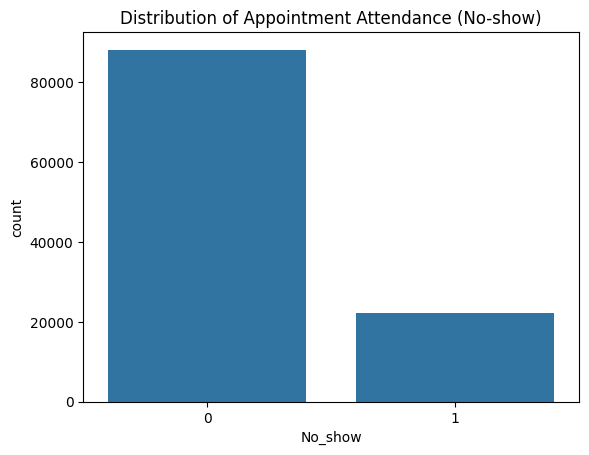

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot target distribution
sns.countplot(x="No_show", data=df_clean)
plt.title("Distribution of Appointment Attendance (No-show)")
plt.show()

The dataset shows that the majority of patients attend their appointments, while a smaller proportion miss them. This indicates a class imbalance, which should be considered during model evaluation.

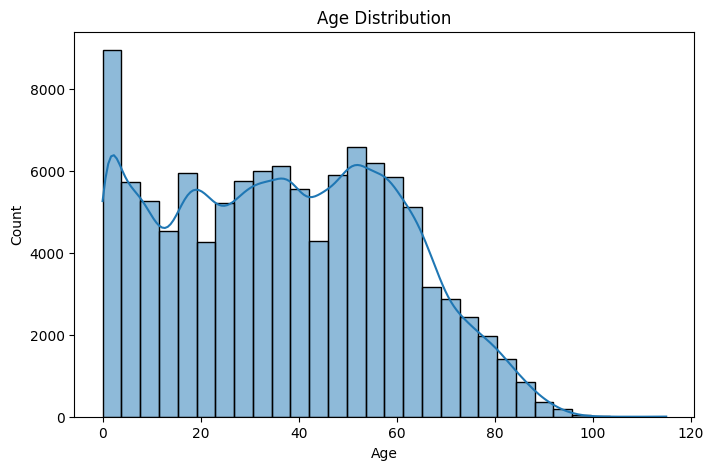

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

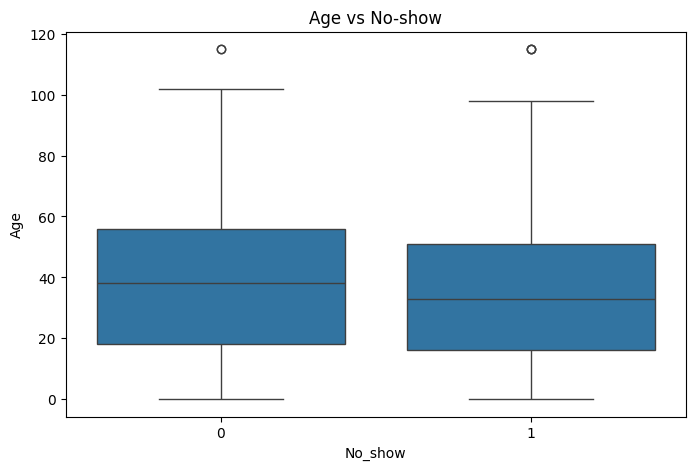

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="No_show", y="Age", data=df_clean)
plt.title("Age vs No-show")
plt.show()

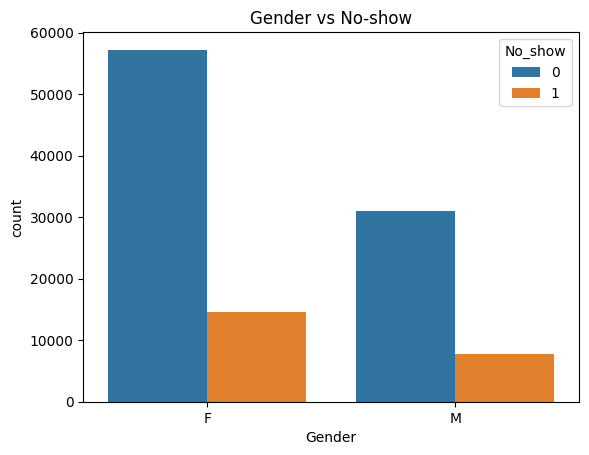

In [ ]:
sns.countplot(x="Gender", hue="No_show", data=df_clean)
plt.title("Gender vs No-show")
plt.show()

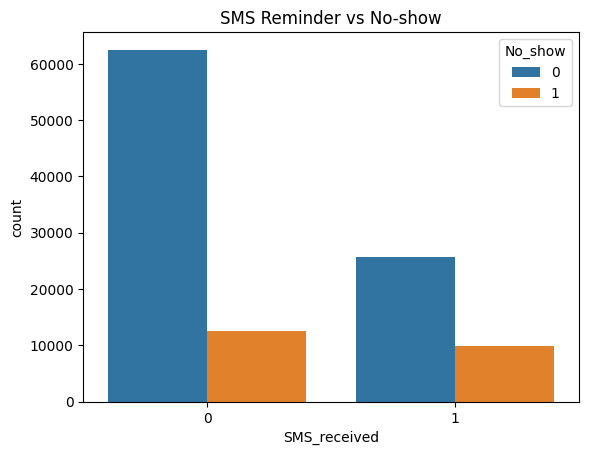

In [ ]:
sns.countplot(x="SMS_received", hue="No_show", data=df_clean)
plt.title("SMS Reminder vs No-show")
plt.show()

Patients who did not receive SMS reminders appear more likely to miss appointments, suggesting that reminder systems may play a role in improving attendance.

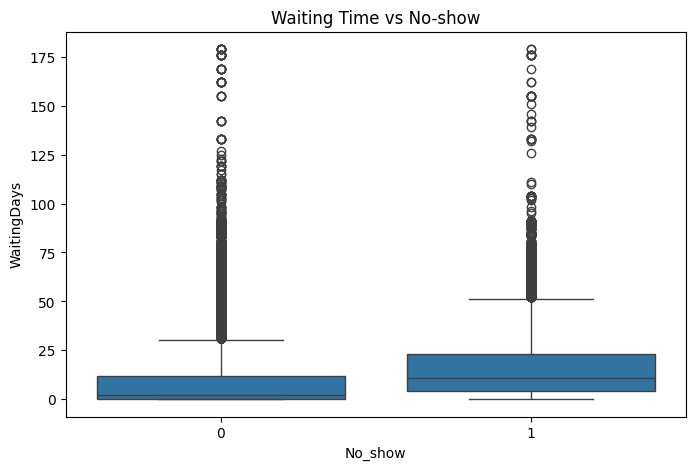

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="No_show", y="WaitingDays", data=df_clean)
plt.title("Waiting Time vs No-show")
plt.show()

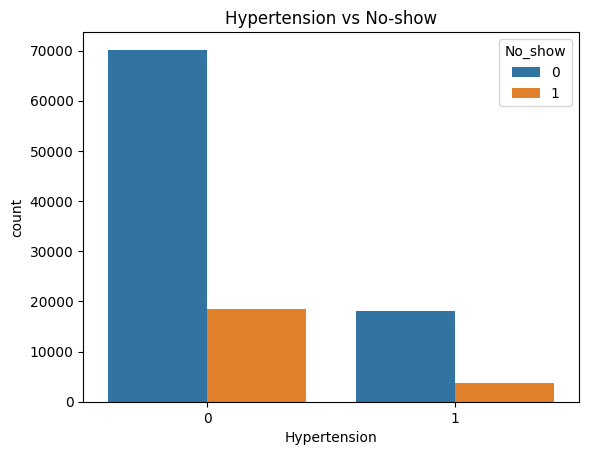

In [ ]:
sns.countplot(x="Hypertension", hue="No_show", data=df_clean)
plt.title("Hypertension vs No-show")
plt.show()

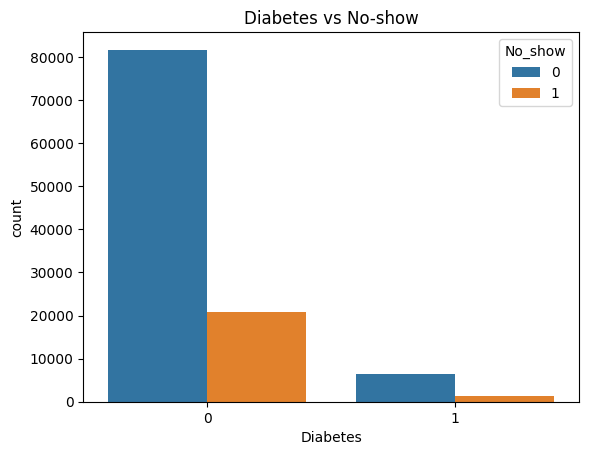

In [ ]:
sns.countplot(x="Diabetes", hue="No_show", data=df_clean)
plt.title("Diabetes vs No-show")
plt.show()

## Key Insights from Exploratory Data Analysis (EDA)

The exploratory analysis revealed several key patterns:

- There is a clear class imbalance, with most patients attending appointments.
- Waiting time is strongly associated with no-show behavior, where longer delays increase the likelihood of missed appointments.
- SMS reminders appear to slightly improve attendance, suggesting a positive but limited effect.
- Age does not show a strong distinction between attending and non-attending patients.
- Patients with chronic conditions (e.g., diabetes) tend to be more consistent in attending appointments.

Overall, waiting time and reminder systems are the most influential factors, while age plays a less significant role. These insights will guide feature selection and model development.

# 5.***Feature Preparation and Data Splitting***

---






In this section, the dataset is prepared for machine learning by selecting relevant features, encoding categorical variables, and splitting the data into training and testing sets.

In [ ]:
# Define target variable
y = df_clean["No_show"]

# Define feature set (drop target column)
X = df_clean.drop(columns=["No_show"])

In [ ]:
# Drop raw date columns (we already extracted useful features)
X = X.drop(columns=["ScheduledDay", "AppointmentDay"])

In [ ]:
# Convert categorical variables using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.shape

(110521, 99)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(88416, 99)
(22105, 99)


## Data Preparation Summary

At this stage, the dataset has been fully prepared for machine learning:
- Target variable was separated from input features
- Irrelevant columns were removed
- Categorical variables were encoded into numerical format
- The dataset was split into training and testing sets

The data is now ready for model training.

# 6. ***Model Training (Logistic Regression)***

---


In this section, a baseline classification model is trained to predict appointment no-show behavior.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.38      0.02      0.03      4463

    accuracy                           0.80     22105
   macro avg       0.59      0.50      0.46     22105
weighted avg       0.71      0.80      0.71     22105



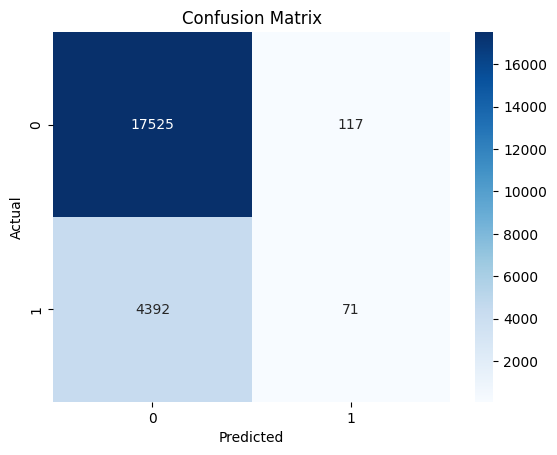

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Model Evaluation Insights

The logistic regression model achieved an overall accuracy of 80%, which appears acceptable at first glance. However, a deeper analysis reveals significant limitations.

The model performs very well in predicting patients who attend appointments (class 0), achieving a recall of 99%. In contrast, it performs poorly in identifying patients who miss appointments (class 1), with a recall of only 2%.

This indicates that the model is heavily biased toward the majority class, likely due to class imbalance in the dataset. As a result, the model tends to predict most patients as attending, failing to effectively capture no-show cases.

Therefore, accuracy alone is not a reliable metric in this scenario, and additional techniques are required to improve model performance, particularly for the minority class.

# 7. Model Improvement

---


In this section, model performance is improved by addressing class imbalance and testing a more advanced algorithm.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Improved model with class_weight
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train
model_balanced.fit(X_train, y_train)

# Predict
y_pred_balanced = model_balanced.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.86      0.67      0.76     17642
           1       0.31      0.58      0.40      4463

    accuracy                           0.65     22105
   macro avg       0.59      0.63      0.58     22105
weighted avg       0.75      0.65      0.68     22105



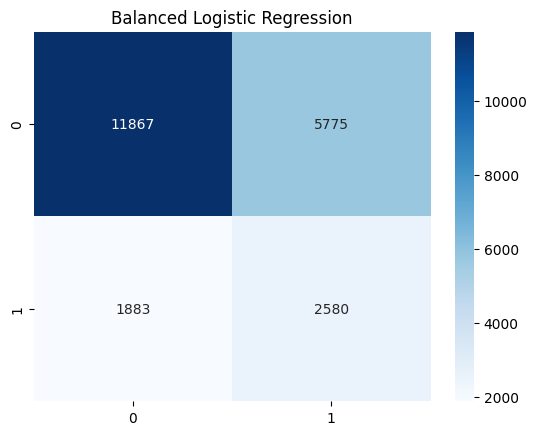

In [ ]:
cm = confusion_matrix(y_test, y_pred_balanced)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Balanced Logistic Regression")
plt.show()

## Improved Model Insights

After applying class balancing, the logistic regression model showed a significant improvement in detecting no-show cases.

The recall for the no-show class increased from 2% to 58%, indicating a much better ability to identify patients who are likely to miss their appointments.

However, this improvement came at the cost of reduced overall accuracy and an increase in false positive predictions. This trade-off is expected when handling class imbalance.

Overall, the balanced model provides a more meaningful and practical solution, as identifying no-show patients is more critical than simply maximizing accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87     17642
           1       0.39      0.21      0.28      4463

    accuracy                           0.78     22105
   macro avg       0.61      0.56      0.57     22105
weighted avg       0.74      0.78      0.75     22105



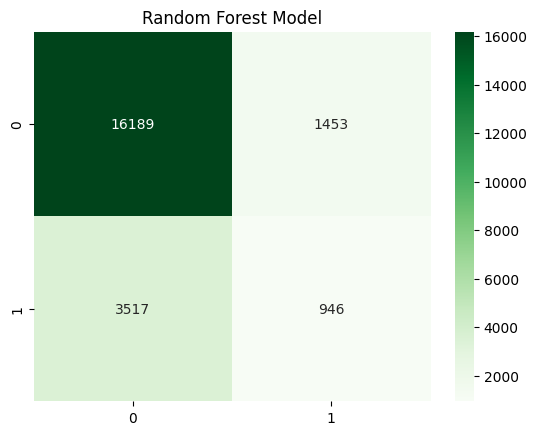

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Model")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=3,  # مهم لعلاج imbalance
    random_state=42
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.66      0.76     17642
           1       0.33      0.66      0.44      4463

    accuracy                           0.66     22105
   macro avg       0.61      0.66      0.60     22105
weighted avg       0.77      0.66      0.70     22105



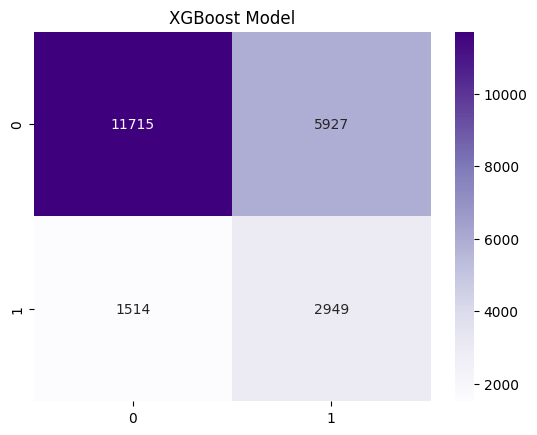

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Purples")
plt.title("XGBoost Model")
plt.show()

## Final Model Evaluation and Selection

An advanced XGBoost model was implemented to further improve prediction performance.

The results show that XGBoost achieved the highest recall for the no-show class (66%), outperforming all previous models. This indicates a significantly improved ability to identify patients who are likely to miss their appointments.

Although the overall accuracy is lower compared to some models, this trade-off is acceptable in this context. From a biomedical informatics perspective, correctly identifying no-show patients is more important than maximizing overall accuracy.

Therefore, XGBoost was selected as the final model, as it provides the most effective balance between performance and clinical relevance.

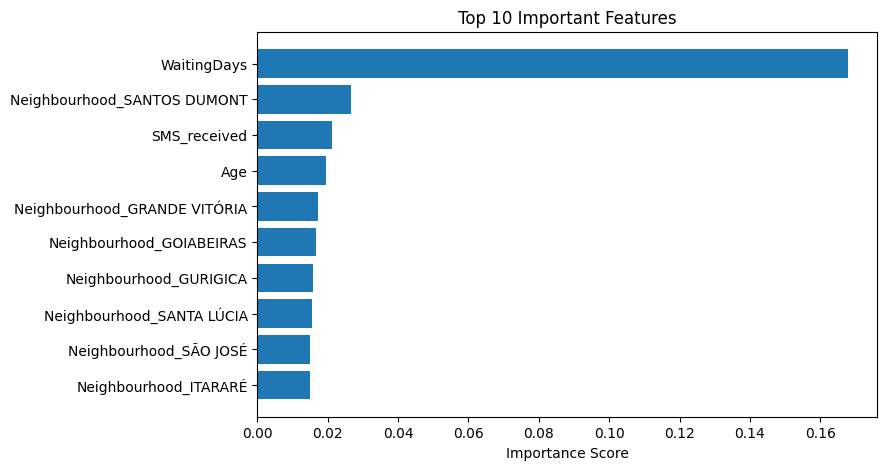

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = xgb_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Top 10
top_features = feature_importance_df.head(10)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

## Feature Importance Insights

The feature importance analysis reveals that waiting time is the most influential factor in predicting no-show behavior. Patients with longer waiting periods are significantly more likely to miss their appointments.

Other variables such as SMS reminders and patient age also contribute to the prediction, although to a lesser extent.

Additionally, certain geographical locations (neighbourhoods) appear to influence attendance behavior, suggesting that social or accessibility factors may play a role.

Overall, the findings highlight the importance of reducing waiting times and improving reminder systems to enhance patient attendance.

## Model Performance Comparison

---



---



---



The performance of different machine learning models was evaluated and compared as follows:

| Model                          | Accuracy | Recall (No-show) | Precision (No-show) |
|--------------------------------|----------|------------------|---------------------|
| Logistic Regression            | 0.80     | 0.02             | 0.38                |
| Balanced Logistic Regression   | 0.65     | 0.58             | 0.31                |
| Random Forest                  | 0.78     | 0.21             | 0.39                |
| XGBoost                        | 0.66     | 0.66             | 0.33                |

### Summary

- The standard Logistic Regression achieved the highest accuracy but failed to detect no-show cases effectively.
- Balanced Logistic Regression significantly improved recall for no-show patients.
- Random Forest improved overall accuracy but still struggled with detecting no-show cases.
- XGBoost provided the best balance, achieving the highest recall for no-show prediction, making it the most suitable model for this task. **bold text** bold text